# Superstore Sales Analysis
### Analisis performa penjualan dan profitabilitas retail Superstore (2014-2017)

**Tujuan project:** Mengidentifikasi kategori produk, wilayah, dan segmen pelanggan mana yang paling menguntungkan (dan mana yang merugi), untuk memberikan rekomendasi bisnis berbasis data.

**Dataset:** [Superstore Dataset - Kaggle](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) — 9.994 transaksi retail dari tahun 2014-2017.

**Pertanyaan bisnis yang dijawab:**
1. Kategori/sub-kategori mana yang paling untung vs paling rugi?
2. Bagaimana tren penjualan dari waktu ke waktu?
3. Wilayah (region) mana yang performanya paling baik/buruk?
4. Apakah diskon berpengaruh terhadap profit?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/Sample_-_Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 1. Data Quality Check

Sebelum analisis, kita cek dulu kondisi data: apakah ada nilai kosong (missing values) atau baris duplikat yang perlu dibersihkan.

In [2]:
print("Jumlah baris & kolom:", df.shape)
print("\nMissing values per kolom:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "Tidak ada missing values.")
print("\nJumlah baris duplikat:", df.duplicated().sum())
print("\nRentang tanggal order:", df['Order Date'].min().date(), "s/d", df['Order Date'].max().date())

Jumlah baris & kolom: (9994, 21)

Missing values per kolom:
Tidak ada missing values.

Jumlah baris duplikat: 0

Rentang tanggal order: 2014-01-03 s/d 2017-12-30


**Hasil:** Dataset ini sudah bersih — tidak ada missing values maupun baris duplikat, sehingga kita bisa langsung masuk ke tahap eksplorasi tanpa perlu proses cleaning tambahan.

## 2. Ringkasan Metrik Utama

In [3]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df['Order ID'].nunique()

print(f"Total Sales     : ${total_sales:,.0f}")
print(f"Total Profit    : ${total_profit:,.0f}")
print(f"Profit Margin   : {profit_margin:.1f}%")
print(f"Total Orders    : {total_orders:,}")

Total Sales     : $2,297,201
Total Profit    : $286,397
Profit Margin   : 12.5%
Total Orders    : 5,009


## 3. Pertanyaan Bisnis #1 — Sub-kategori mana yang paling untung vs paling rugi?

In [4]:
subcat = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean')
).sort_values('Total_Profit')

subcat

,Total_Sales,Total_Profit,Avg_Discount
Sub-Category,,,
Tables,206965.5320,-17725.4811,0.261285
Bookcases,114879.9963,-3472.5560,0.211140
Supplies,46673.5380,-1189.0995,0.076842
Fasteners,3024.2800,949.5182,0.082028
Machines,189238.6310,3384.7569,0.306087
Labels,12486.3120,5546.2540,0.068681
Art,27118.7920,6527.7870,0.074874
Envelopes,16476.4020,6964.1767,0.080315
Furnishings,91705.1640,13059.1436,0.138349


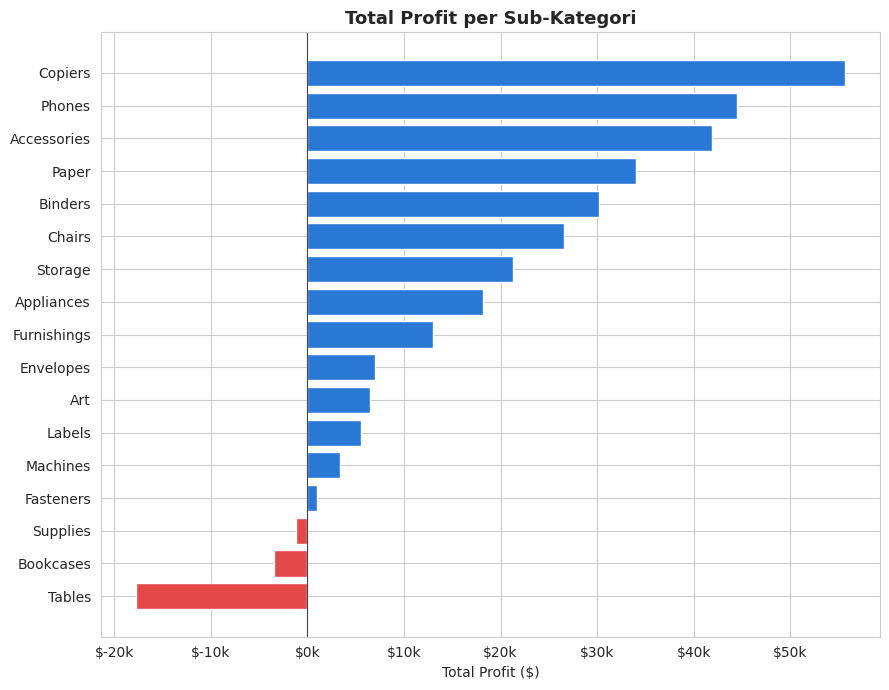

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e34948' if v < 0 else '#2a78d6' for v in subcat['Total_Profit']]
ax.barh(subcat.index, subcat['Total_Profit'], color=colors)
ax.set_title('Total Profit per Sub-Kategori', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}k'))
ax.axvline(0, color='#444', linewidth=0.8)
plt.tight_layout()
plt.savefig('../images/profit_per_subcategory.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:** `Tables`, `Bookcases`, dan `Supplies` justru merugi meskipun beberapa di antaranya (terutama Tables) punya total sales yang tinggi. Ini indikasi kuat bahwa masalahnya bukan di volume penjualan, tapi di margin/diskon.

## 4. Pertanyaan Bisnis #2 — Apakah diskon memengaruhi profit?

Korelasi Discount vs Profit: -0.219


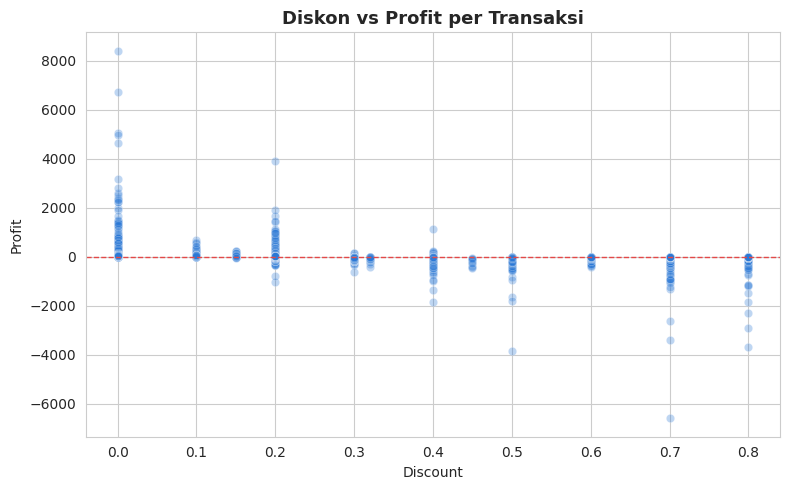

In [6]:
correlation = df[['Discount', 'Profit']].corr().iloc[0, 1]
print(f"Korelasi Discount vs Profit: {correlation:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.3, ax=ax, color='#2a78d6')
ax.axhline(0, color='#e34948', linewidth=1, linestyle='--')
ax.set_title('Diskon vs Profit per Transaksi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/discount_vs_profit.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:** Korelasi negatif (sekitar -0.22) menunjukkan bahwa semakin besar diskon yang diberikan, semakin besar pula kemungkinan transaksi tersebut merugi (banyak titik merah di bawah garis nol saat diskon di atas 20%).

## 5. Pertanyaan Bisnis #3 — Bagaimana tren penjualan dari waktu ke waktu?

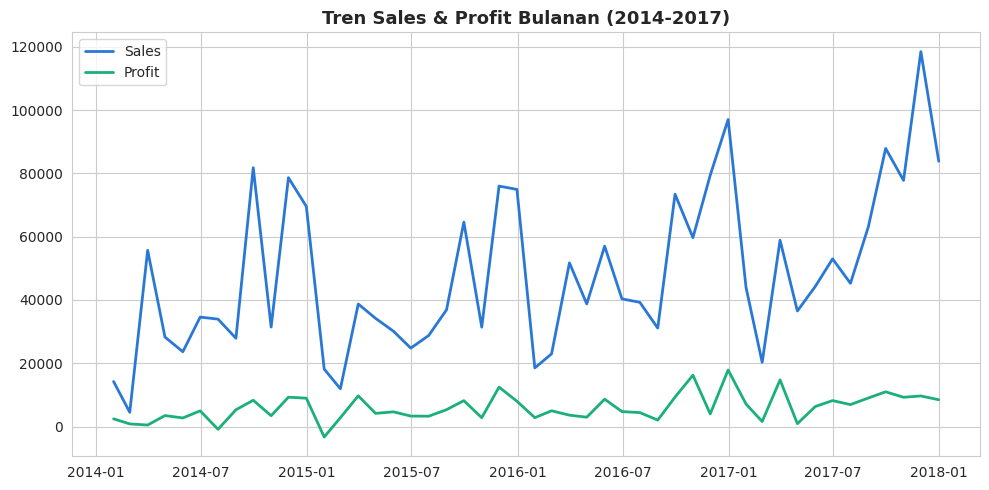

In [7]:
monthly = df.set_index('Order Date').resample('ME')[['Sales', 'Profit']].sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly.index, monthly['Sales'], label='Sales', color='#2a78d6', linewidth=2)
ax.plot(monthly.index, monthly['Profit'], label='Profit', color='#1baf7a', linewidth=2)
ax.set_title('Tren Sales & Profit Bulanan (2014-2017)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../images/monthly_trend.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:** Penjualan menunjukkan pola musiman yang jelas — cenderung naik signifikan menjelang akhir tahun (November-Desember), kemungkinan terkait musim belanja liburan.

## 6. Pertanyaan Bisnis #4 — Wilayah (region) mana yang paling baik performanya?

In [8]:
region = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values('Total_Profit', ascending=False)
region['Profit_Margin_%'] = (region['Total_Profit'] / region['Total_Sales'] * 100).round(1)

region

,Total_Sales,Total_Profit,Profit_Margin_%
Region,,,
West,725457.8245,108418.4489,14.9
East,678781.2400,91522.7800,13.5
South,391721.9050,46749.4303,11.9
Central,501239.8908,39706.3625,7.9


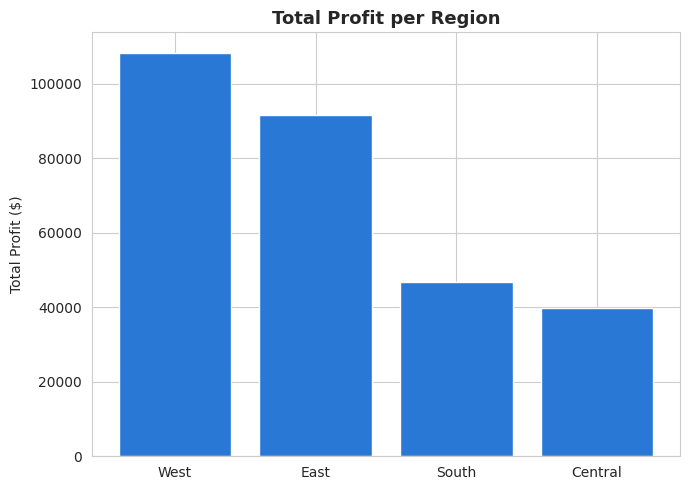

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(region.index, region['Total_Profit'], color='#2a78d6')
ax.set_title('Total Profit per Region', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('../images/profit_per_region.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Kesimpulan & Rekomendasi Bisnis

**Temuan utama:**
1. Sub-kategori **Tables** adalah masalah profitabilitas terbesar — merugi meski penjualannya tinggi, kemungkinan besar karena diskon yang terlalu agresif.
2. **Bookcases** dan **Supplies** juga konsisten merugi dan perlu ditinjau ulang strategi harganya.
3. Ada korelasi negatif antara besaran diskon dan profit — diskon di atas ~20% berisiko membuat transaksi merugi.
4. Penjualan punya pola musiman yang jelas, naik tajam di kuartal 4 (November-Desember).
5. Region **West** dan **East** secara konsisten menghasilkan profit margin lebih baik dibanding **Central**.

**Rekomendasi:**
- Tinjau ulang kebijakan diskon untuk kategori Tables, Bookcases, dan Supplies — pertimbangkan batas maksimum diskon di kisaran 15-20%.
- Manfaatkan pola musiman kuartal 4 untuk perencanaan stok dan strategi promosi yang lebih matang.
- Pelajari strategi region West/East (harga, mix produk, biaya operasional) untuk diterapkan ke region Central yang tertinggal.


## 8. Implementasi Query SQL (sqlite3)

Sebagai bagian dari integrasi database SQL, seluruh data transaksi Superstore telah diimpor ke database **`sql/superstore.db`** dengan format kolom tanggal ISO (`YYYY-MM-DD`).

Berikut adalah demonstrasi koneksi ke database SQLite menggunakan library standard `sqlite3` dan mengeksekusi query analisis dari file `sql/queries.sql`.

In [ ]:
import sqlite3
import pandas as pd

# Hubungkan ke database SQLite superstore.db
db_path = '../sql/superstore.db'
conn = sqlite3.connect(db_path)

print('Koneksi ke superstore.db berhasil!')

### Contoh Query 1: Analisis Profitabilitas per Sub-Kategori Produk (SQL)

Query SQL ini mengagregasi total sales, total profit, dan margin profitabilitas untuk setiap sub-kategori produk.

In [ ]:
query_subcat = '''
SELECT 
    Sub_Category,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(AVG(Discount) * 100, 2) AS avg_discount_pct,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS profit_margin_pct
FROM superstore
GROUP BY Sub_Category
ORDER BY total_profit DESC;
'''

df_sql_subcat = pd.read_sql_query(query_subcat, conn)
df_sql_subcat

### Contoh Query 2: Top 10 Pelanggan dengan Kontribusi Profit Tertinggi (SQL)

Query SQL ini mengidentifikasi 10 pelanggan terbaik berdasarkan kontribusi total profit.

In [ ]:
query_top_customers = '''
SELECT 
    Customer_ID,
    Customer_Name,
    Segment,
    COUNT(DISTINCT Order_ID) AS total_orders,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS profit_margin_pct
FROM superstore
GROUP BY Customer_ID, Customer_Name, Segment
ORDER BY total_profit DESC
LIMIT 10;
'''

df_sql_top_customers = pd.read_sql_query(query_top_customers, conn)
df_sql_top_customers

In [ ]:
# Tutup koneksi database setelah selesai
conn.close()